In [192]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import time
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

1. a) Pick a weight vector w∗ ∈ R 10 whose Euclidean...

In [193]:
ws = np.random.randn(10)
norm = np.linalg.norm(ws)

wsn = ws / norm

1. b) Next, generate a training set of size m of the form {(x1, y1), . . . ,(xm, ym)}

In [194]:
columns = 10
iterations = 5000
learning_rate = 0.1

def sigmoid(x):
    return 1/(1 + np.exp(-x))

def data_generation(m, columns, wsn):
    X = np.random.randn(m, columns)
    y = np.zeros(m)
    for i in range(m):
        dotp = np.dot(wsn, X[i])
        xc = sigmoid(dotp)
        uniform = np.random.uniform(0, 1)
        if uniform <= xc:
            y[i] = 1
        else:
            y[i] = 0

    return X, y

Learning part.

Algorithm 1

In [195]:
def logistic_regression(X, y, iterations):
    log_regression = LogisticRegression(fit_intercept=False, max_iter=iterations)
    log_regression.fit(X, y)

    return log_regression.coef_.flatten()

Algorithm 2

Calculate derrivative

pdL/ pdw' = pdL/pd sig * pd sig/ pd z * pd z / pd w'

pdL/pd sig = 2*1/2 (sig -y) * 1 = (sig - y)
pd sig / pd z = (1 / (1 + e ^ -z))' = ((1 + e ^ -z)^-1)' = ((-1) (1 + e^-z) ^ -2) * (-1)(e ^ -z) = (e ^ -z) / (1 + e ^ -z) ^ 2 = sig * sig * e ^ -z = sig * (1 - sig)
pd z / pd w' = x

pdL / pdw' = (sig - y) * (sig * (1 - sig)) * x 

Averaged over gradient  = 1/m * sum(pdL / pd w')

In [196]:
def gradeint_descent(X, y, iterations, learning_rate = 0.1):
    w = np.random.randn(columns)
    m = len(X)

    for epoch in range(iterations):
        dotp = np.dot(X, w)
        ypred = sigmoid(dotp)

        error = ypred - y
        grad = 1/m * (np.dot(X.T, (error * ypred *(1 - ypred))))

        w = w - learning_rate * grad

    return w

Algorithm 3

In [197]:
def stchastic_gradient_descent(X, y, iterations, learning_rate = 0.1):
    w = np.random.randn(columns)
    m = len(X)

    for epoch in range(iterations):
        point = np.random.randint(0, m)
        x_p = X[point]
        y_p = y[point]

        dotp = np.dot(x_p, w)
        ypred = sigmoid(dotp)

        error = ypred - y_p
        grad = error * ypred * (1 - ypred) * x_p
        
        w = w - learning_rate * grad
        
    return w

In [198]:
def weight_distance(wsn, learned_weights):    
    result = np.linalg.norm(wsn - learned_weights)
    return result

def experimenting(m, trials = 10):
    log_regressin_res = []
    gd_res = []
    sgd_res = []

    algo1_total_time = 0
    algo2_total_time = 0
    algo3_total_time = 0

    start_time = time.time()

    for i in range(trials):
        ws = np.random.randn(10)
        norm = np.linalg.norm(ws)
        wsn = ws / norm

        X, y = data_generation(m, columns, wsn)

        # Algorithm 1
        algo1_time_start = time.time()
        log_regression_weights = logistic_regression(X, y, iterations)
        dist1 = weight_distance(wsn, log_regression_weights)
        log_regressin_res.append(dist1)
        algo1_time_stop = time.time()
        algo1_total_time += algo1_time_stop - algo1_time_start
       
        # Algorithm 2
        algo2_time_start = time.time()
        gd_weights = gradeint_descent(X, y, iterations, learning_rate)
        dist2 = weight_distance(wsn, gd_weights)
        gd_res.append(dist2)
        algo2_time_stop = time.time()
        algo2_total_time += algo2_time_stop - algo2_time_start

        # Algorithm 3
        algo3_time_start = time.time()
        sgd_weights = stchastic_gradient_descent(X, y, iterations, learning_rate)
        dist3 = weight_distance(wsn, sgd_weights)
        sgd_res.append(dist3)
        algo3_time_stop = time.time()
        algo3_total_time += algo3_time_stop - algo3_time_start

    end_time = time.time()

    avg_log_regression = np.mean(log_regressin_res, axis=0)
    avg_gd = np.mean(gd_res, axis=0)
    avg_sgd = np.mean(sgd_res, axis=0)
    total_time = end_time - start_time

    print(f"Number of samples={m}, Total Time={total_time:.2f}s, Algo1 time: {algo1_total_time}s, Algo2 time: {algo2_total_time}s, Algo3 time: {algo3_total_time}s,  Logistic={avg_log_regression}, GD={avg_gd}, SGD={avg_sgd}")
    
    return avg_log_regression, avg_gd, avg_sgd, total_time
    

In [199]:
m_values = [50, 100, 150, 200, 250]
avg_logreg_list = []
avg_gd_list = []
avg_sgd_list = []
times = []

for m in m_values:
    avg_logreg, avg_gd, avg_sgd, total_time = experimenting(m)

    avg_logreg_list.append(avg_logreg)
    avg_gd_list.append(avg_gd)
    avg_sgd_list.append(avg_sgd)
    
    times.append(total_time)

Number of samples=50, Total Time=0.86s, Algo1 time: 0.018044233322143555s, Algo2 time: 0.498077392578125s, Algo3 time: 0.33965015411376953s,  Logistic=1.1459972395808333, GD=2.26966283932658, SGD=2.561170758222094
Number of samples=100, Total Time=0.95s, Algo1 time: 0.018811464309692383s, Algo2 time: 0.5715851783752441s, Algo3 time: 0.35649847984313965s,  Logistic=0.774122542200358, GD=1.034701138851182, SGD=1.2053875099572415
Number of samples=150, Total Time=0.99s, Algo1 time: 0.017213821411132812s, Algo2 time: 0.6217508316040039s, Algo3 time: 0.3423283100128174s,  Logistic=0.6222316708321359, GD=0.8508201007128238, SGD=1.0110298690021255
Number of samples=200, Total Time=1.01s, Algo1 time: 0.016910791397094727s, Algo2 time: 0.641812801361084s, Algo3 time: 0.3400280475616455s,  Logistic=0.5180938420894882, GD=0.5754743459100806, SGD=0.8232197483891751
Number of samples=250, Total Time=1.03s, Algo1 time: 0.016281843185424805s, Algo2 time: 0.6677465438842773s, Algo3 time: 0.33321404457

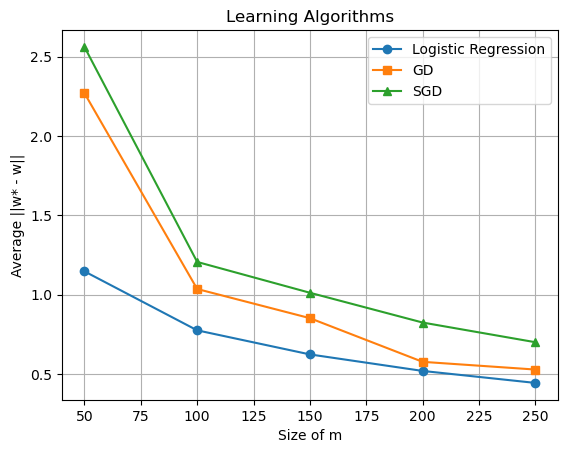

In [200]:

plt.plot(m_values, avg_logreg_list, marker='o', label='Logistic Regression')
plt.plot(m_values, avg_gd_list, marker='s', label='GD')
plt.plot(m_values, avg_sgd_list, marker='^', label='SGD')
plt.xlabel('Size of m')
plt.ylabel('Average ||w* - w||')
plt.title('Learning Algorithms')
plt.legend()
plt.grid(True)
plt.show()

2.  In this problem we will see a toy example of how to use AdaBoost. Please read the documentation on AdaBoostClassifier in sklearn ...

In [ ]:
cancer = datasets.load_breast_cancer()

X = cancer.data
y = cancer.target

depths = [1, 2, 3, 4, 5]
accuracy = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    ada = AdaBoostClassifier(base_estimator=dt, n_estimators=50, random_state=42)

    scores = cross_val_score(ada, X, y, cv=10, scoring='accuracy')    

    accuracy.append(np.mean(scores))


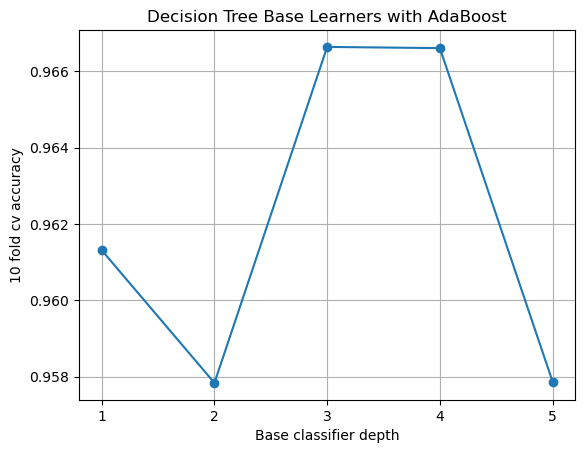

In [202]:
plt.plot(depths, accuracy, marker='o')
plt.xlabel('Base classifier depth')
plt.ylabel('10 fold cv accuracy')
plt.title('Decision Tree Base Learners with AdaBoost')
plt.grid(True)
plt.xticks(depths)
plt.show()